# Day 2 Session 2: SIR and Compartment Models


> **Participant notebook:** Work through the examples in order. For exercises that ask you to modify an existing example, a copied workspace or starter cell is included so you can change the named values without editing the original demonstration cell.


### SIR Model with a Total Population

We now move from general dynamical systems to epidemiological models. The **SIR model** divides a population into three compartments:

- $S(t)$: susceptible individuals
- $I(t)$: infected individuals
- $R(t)$: recovered or removed individuals

Because these variables represent counts, we include the total population

$$
N = S(t)+I(t)+R(t).
$$

The infection term is scaled by $N$:

$$
\frac{\beta S(t)I(t)}{N}.
$$

This keeps the transmission term interpretable when the population size changes.

The SIR model is

$$
\begin{aligned}
\frac{dS}{dt} &= -\frac{\beta S I}{N},\\
\frac{dI}{dt} &= \frac{\beta S I}{N}-\gamma I,\\
\frac{dR}{dt} &= \gamma I.
\end{aligned}
$$

Here:

- $\beta$ is the transmission rate.
- $\gamma$ is the recovery rate.
- $N$ is the total population.

For this workshop example, we will use

$$
S(0)=495,\qquad I(0)=5,\qquad R(0)=0,\qquad N=500.
$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def simulate_sir(beta=0.3, gamma=0.1, S0=495, I0=5, R0=0, days=100, delta_t=0.1):
    t_grid = np.arange(0, days + delta_t, delta_t)
    sol = np.zeros((len(t_grid), 3))
    sol[0] = np.array([S0, I0, R0], dtype=float)

    for n in range(1, len(t_grid)):
        S, I, R = sol[n - 1]
        N = S + I + R

        dS = -beta * S * I / N
        dI = beta * S * I / N - gamma * I
        dR = gamma * I

        sol[n] = sol[n - 1] + delta_t * np.array([dS, dI, dR])

    return t_grid, sol


t_sir, sir_sol = simulate_sir()

plt.figure(figsize=(8, 4))
plt.plot(t_sir, sir_sol, label=["S", "I", "R"])
plt.title("SIR Model with Total Population $N$")
plt.xlabel("Days")
plt.ylabel("Number of people")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Total population at the beginning:", sir_sol[0].sum())
print("Total population at the end:", sir_sol[-1].sum())

### Exercise 1: Interpreting the SIR Model

**Core:** Change $\beta$ and $\gamma$ and describe what happens to the infected curve.

**Stretch:** Find a parameter setting where the outbreak stays small.


## Formal Compartment Flow Charts

A compartment model can be written in two equivalent ways:

1. as a system of differential equations;
2. as a flow chart showing movement between compartments.

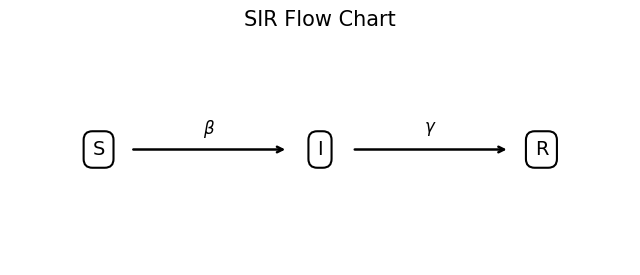
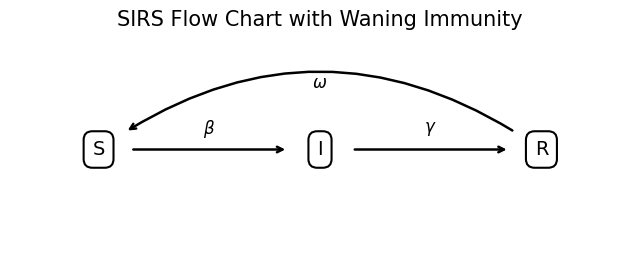
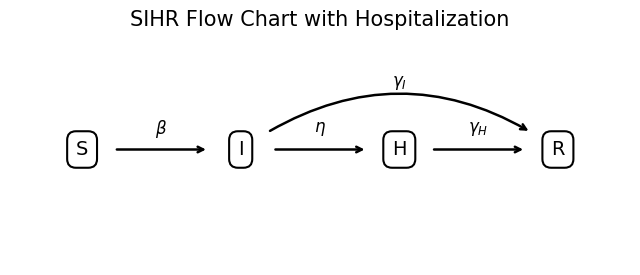


In [ ]:
def draw_compartment_diagram(nodes, edges, title, figsize=(8, 3)):
    """Draw a simple formal compartment flow chart using matplotlib."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    # Draw compartments.
    for label, (x, y) in nodes.items():
        ax.text(
            x, y, label,
            ha="center", va="center",
            fontsize=14,
            bbox=dict(boxstyle="round,pad=0.45", linewidth=1.5, facecolor="white")
        )

    # Draw arrows.
    for start, end, rate, rad in edges:
        x1, y1 = nodes[start]
        x2, y2 = nodes[end]
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.8,
                shrinkA=25,
                shrinkB=25,
                connectionstyle=f"arc3,rad={rad}"
            )
        )
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        label_offset = 0.18 if rad == 0 else 0.58
        ax.text(mx, my + label_offset, rate, ha="center", va="center", fontsize=12)

    ax.set_title(title, fontsize=15)
    xs = [p[0] for p in nodes.values()]
    ys = [p[1] for p in nodes.values()]
    ax.set_xlim(min(xs) - 1, max(xs) + 1)
    ax.set_ylim(min(ys) - 1, max(ys) + 1)
    plt.show()


# SIR
nodes_sir = {"S": (0, 0), "I": (2.5, 0), "R": (5, 0)}
edges_sir = [
    ("S", "I", r"$\beta $", 0.0),
    ("I", "R", r"$\gamma $", 0.0),
]
draw_compartment_diagram(nodes_sir, edges_sir, "SIR Flow Chart")

# SIRS
nodes_sirs = {"S": (0, 0), "I": (2.5, 0), "R": (5, 0)}
edges_sirs = [
    ("S", "I", r"$\beta $", 0.0),
    ("I", "R", r"$\gamma $", 0.0),
    ("R", "S", r"$\omega $", 0.35),
]
draw_compartment_diagram(nodes_sirs, edges_sirs, "SIRS Flow Chart with Waning Immunity")

# SIHR
nodes_sihr = {"S": (0, 0), "I": (2.2, 0), "H": (4.4, 0), "R": (6.6, 0)}
edges_sihr = [
    ("S", "I", r"$\beta $", 0.0),
    ("I", "H", r"$\alpha \eta $", 0.0),
    ("H", "R", r"$\gamma_H $", 0.0),
    ("I", "R", r"$(1-\alpha)\gamma_I $", -0.35),
]
draw_compartment_diagram(nodes_sihr, edges_sihr, "SIHR Flow Chart with Hospitalization")

### Exercise: From Flow Charts to Dynamical Systems

In this exercise, we will translate compartment flow charts into systems of differential equations.

We assume the total population is

$$
N = S + I + R
$$

for the SIRS model, and

$$
N = S + I + H + R
$$

for the SIHR model.

---


**Task:** Write down the system of differential equations for the SIRS and SIHR model.


### Exercise: Simulating SIRS and SIHR Models with Euler's Method

In this exercise, we will simulate the SIRS and SIHR models using Euler's method.

1. In the SIRS model, what happens to the infected curve when immunity wanes?
2. In the SIHR model, how does changing $\alpha$ affect the hospitalized curve?
3. Which model would be more appropriate if we are interested in influenza hospitalization data?


In [ ]:
# Starter workspace: complete the missing update terms for the SIRS model first.
# Then copy the same Euler pattern to build a SIHR model.

def simulate_sirs_starter(beta=0.3, gamma=0.1, omega=0.03, S0=495, I0=5, R0=0, days=160, delta_t=0.1):
    t_grid = np.arange(0, days + delta_t, delta_t)
    sol = np.zeros((len(t_grid), 3))
    sol[0] = np.array([S0, I0, R0], dtype=float)

    for n in range(1, len(t_grid)):
        S, I, R = sol[n - 1]
        N = S + I + R

        infection = beta * S * I / N
        recovery = gamma * I
        waning_immunity = omega * R

        dS = -infection + waning_immunity
        dI = infection - recovery
        dR = recovery - waning_immunity

        sol[n] = sol[n - 1] + delta_t * np.array([dS, dI, dR])

    return t_grid, sol


t_sirs, sirs_sol = simulate_sirs_starter()
plt.figure(figsize=(8, 4))
plt.plot(t_sirs, sirs_sol, label=["S", "I", "R"])
plt.title("SIRS starter simulation")
plt.xlabel("Days")
plt.ylabel("People")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Try changing omega. What happens to the infected curve?
